# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

**Business framing → Data problem.**

The used car dealership wants to know *what drives the price of a used vehicle* so that it can fine-tune its inventory — i.e., buy and stock cars that will sell at a good margin and price them appropriately.

Reframed as a data problem: this is a **supervised regression task**. The target variable is `price` (continuous), and the goal is to build a model that predicts `price` from vehicle attributes (age, mileage, manufacturer, condition, fuel type, transmission, drivetrain, cylinders, body type, etc.). Beyond raw predictive accuracy, the **primary deliverable is interpretability** — we need to understand which features have the largest effect on price (via regression coefficients and feature importances) so we can translate that into concrete inventory recommendations for a non-technical audience.

**Data mining success criteria:** a model with reasonably low error (Mean Absolute Error and R²) *and* coefficients/feature importances that are stable and interpretable enough to support actionable business recommendations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('data/vehicles.csv')
print(df.shape)
df.head()

(426880, 18)


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [4]:
print(f"Rows: {df.shape[0]:,}, Columns: {df.shape[1]}")
print("\nMissing values (% of rows):")
print((df.isnull().mean() * 100).round(1).sort_values(ascending=False))

Rows: 426,880, Columns: 18

Missing values (% of rows):


size            71.8
cylinders       41.6
condition       40.8
VIN             37.7
drive           30.6
paint_color     30.5
type            21.8
manufacturer     4.1
title_status     1.9
model            1.2
odometer         1.0
fuel             0.7
transmission     0.6
year             0.3
region           0.0
id               0.0
price            0.0
state            0.0
dtype: float64


In [5]:
df[['price','year','odometer']].describe()

,price,year,odometer
count,4.268800e+05,425675.000000,4.224800e+05
mean,7.519903e+04,2011.235191,9.804333e+04
std,1.218228e+07,9.452120,2.138815e+05
min,0.000000e+00,1900.000000,0.000000e+00
25%,5.900000e+03,2008.000000,3.770400e+04
50%,1.395000e+04,2013.000000,8.554800e+04
75%,2.648575e+04,2017.000000,1.335425e+05
max,3.736929e+09,2022.000000,1.000000e+07


In [6]:
# Several data quality issues are visible immediately:
# - price has a minimum of 0 and a max in the billions -- clearly bad/placeholder data
# - year has some very old / missing values
# - odometer has extreme outliers (millions of miles)
print("Rows with price == 0:", (df['price'] == 0).sum())
print("Rows with price > 200,000:", (df['price'] > 200000).sum())
print("Rows with odometer > 500,000:", (df['odometer'] > 500000).sum())
print("Rows with year < 1980:", (df['year'] < 1980).sum())
print("Duplicate ids:", df['id'].duplicated().sum())

Rows with price == 0: 32895
Rows with price > 200,000: 124
Rows with odometer > 500,000: 1386
Rows with year < 1980: 8413
Duplicate ids: 0


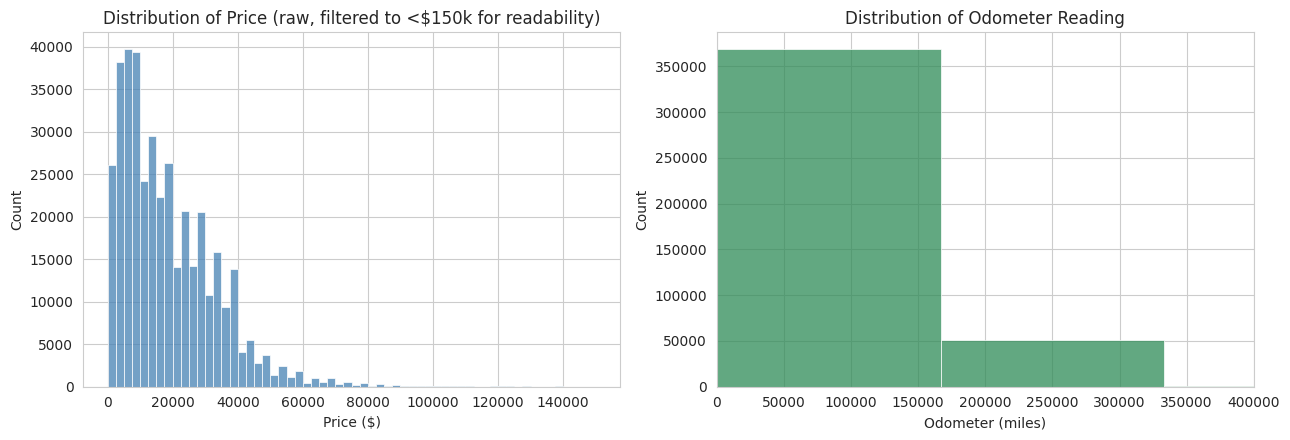

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df.loc[(df['price']>0) & (df['price']<150000), 'price'], bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Price (raw, filtered to <$150k for readability)')
axes[0].set_xlabel('Price ($)')

sns.histplot(df['odometer'].dropna(), bins=60, ax=axes[1], color='seagreen')
axes[1].set_xlim(0, 400000)
axes[1].set_title('Distribution of Odometer Reading')
axes[1].set_xlabel('Odometer (miles)')
plt.tight_layout()
plt.show()

**Data understanding notes:**

- `price`, `odometer`, and `year` all contain implausible extreme values that need to be filtered out (e.g., \$0 or multi-billion-dollar prices, million-mile odometers, cars listed with `year` under 1900).
- `VIN`, `region`, and `model` are extremely high-cardinality text fields; `VIN` is essentially a unique identifier and not useful for a price-driver model, and `model` has thousands of unique values and will be excluded from the baseline modeling (manufacturer captures much of the same signal at manageable cardinality).
- `size` is missing for ~72% of rows — too sparse to be useful, so it will be dropped.
- `condition`, `cylinders`, `drive`, `paint_color`, and `type` all have a meaningful chunk of missing data (20–40%), but rather than dropping these rows (which would lose a lot of data), we'll encode missing values as an explicit `"unknown"` category, since an unlisted attribute can itself be informative.
- `manufacturer`, `fuel`, `transmission`, and `title_status` have only small amounts of missing data (<5%) — we'll drop those rows rather than impute, since they are core categorical drivers of price.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [8]:
# Drop columns that aren't useful for a baseline price-driver model:
# - id: unique identifier, no predictive value
# - VIN: unique identifier, ~38% missing
# - region: extremely high cardinality (400+ values), overlaps heavily with `state`
# - model: extremely high cardinality (thousands of values), noisy for a baseline model
# - size: ~72% missing
df_clean = df.drop(columns=['id', 'VIN', 'region', 'model', 'size'])
df_clean.shape

(426880, 13)

In [9]:
# Remove implausible / outlier values in price, year, and odometer
df_clean = df_clean[(df_clean['price'] > 500) & (df_clean['price'] < 100000)]
df_clean = df_clean[(df_clean['year'] >= 1990) & (df_clean['year'] <= 2022)]
df_clean = df_clean[(df_clean['odometer'] >= 0) & (df_clean['odometer'] < 350000)]

# Drop rows missing manufacturer/fuel/transmission/title_status (small % of data)
df_clean = df_clean.dropna(subset=['manufacturer', 'fuel', 'transmission', 'title_status'])

print(f"Rows remaining after cleaning: {df_clean.shape[0]:,} ({df_clean.shape[0]/len(df):.1%} of original)")

Rows remaining after cleaning: 346,071 (81.1% of original)


In [10]:
# For remaining categorical columns with missing values, encode as an explicit 'unknown' category
for c in ['condition', 'cylinders', 'drive', 'paint_color', 'type']:
    df_clean[c] = df_clean[c].fillna('unknown')

df_clean.isnull().sum()

price           0
year            0
manufacturer    0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
type            0
paint_color     0
state           0
dtype: int64

In [11]:
# Feature engineering: convert model year into vehicle age (more intuitive & robust than raw year)
df_clean['age'] = 2022 - df_clean['year']
df_clean = df_clean.drop(columns=['year'])

df_clean.head()

,price,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,age
27,33590,gmc,good,8 cylinders,gas,57923.0,clean,other,unknown,pickup,white,al,8.0
28,22590,chevrolet,good,8 cylinders,gas,71229.0,clean,other,unknown,pickup,blue,al,12.0
29,39590,chevrolet,good,8 cylinders,gas,19160.0,clean,other,unknown,pickup,red,al,2.0
30,30990,toyota,good,8 cylinders,gas,41124.0,clean,other,unknown,pickup,red,al,5.0
31,15000,ford,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,al,9.0


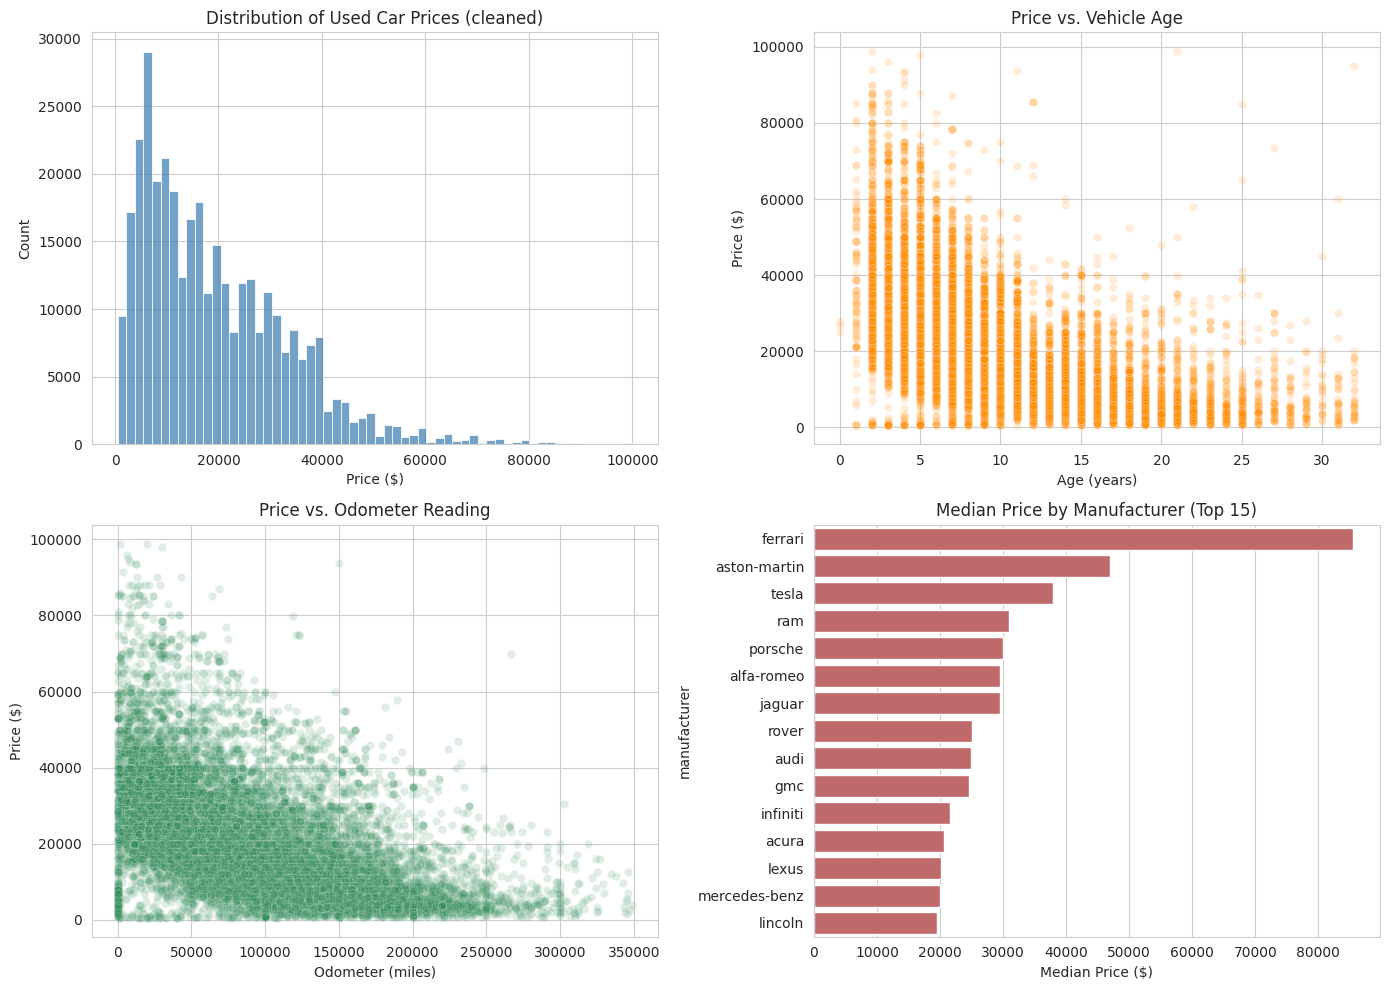

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_clean['price'], bins=60, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Distribution of Used Car Prices (cleaned)')
axes[0,0].set_xlabel('Price ($)')

sample = df_clean.sample(20000, random_state=1)
sns.scatterplot(data=sample, x='age', y='price', alpha=0.15, ax=axes[0,1], color='darkorange')
axes[0,1].set_title('Price vs. Vehicle Age')
axes[0,1].set_xlabel('Age (years)')
axes[0,1].set_ylabel('Price ($)')

sns.scatterplot(data=sample, x='odometer', y='price', alpha=0.15, ax=axes[1,0], color='seagreen')
axes[1,0].set_title('Price vs. Odometer Reading')
axes[1,0].set_xlabel('Odometer (miles)')
axes[1,0].set_ylabel('Price ($)')

top_makes = df_clean.groupby('manufacturer')['price'].median().sort_values(ascending=False).head(15)
sns.barplot(x=top_makes.values, y=top_makes.index, ax=axes[1,1], color='indianred')
axes[1,1].set_title('Median Price by Manufacturer (Top 15)')
axes[1,1].set_xlabel('Median Price ($)')

plt.tight_layout()
plt.show()

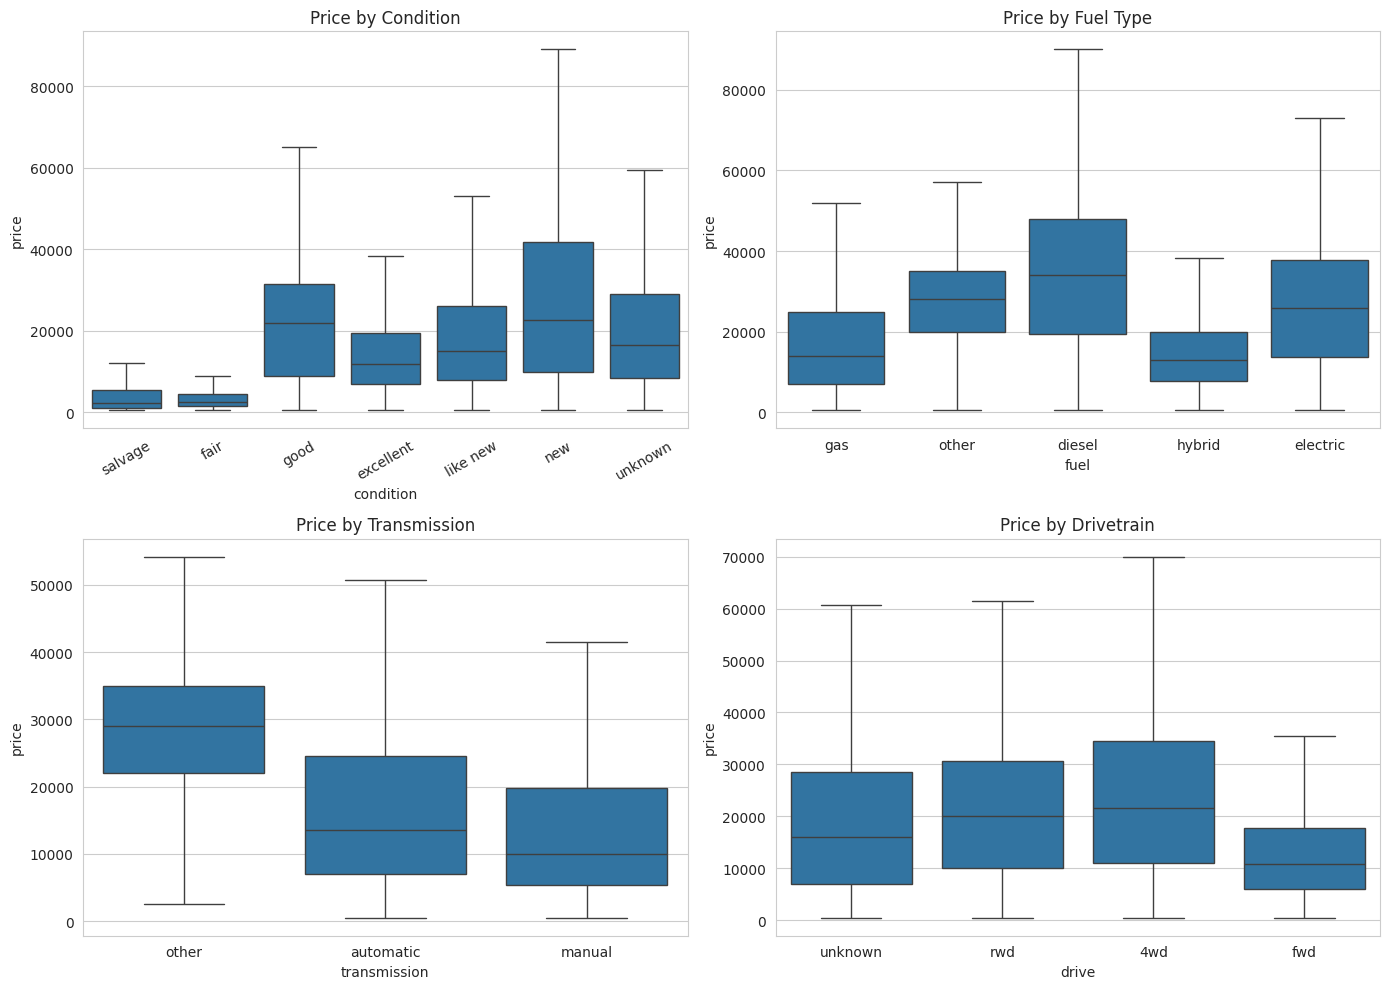

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
order_cond = ['salvage','fair','good','excellent','like new','new','unknown']
order_cond = [c for c in order_cond if c in df_clean['condition'].unique()]

sns.boxplot(data=df_clean, x='condition', y='price', order=order_cond, ax=axes[0,0], showfliers=False)
axes[0,0].set_title('Price by Condition')
axes[0,0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_clean, x='fuel', y='price', ax=axes[0,1], showfliers=False)
axes[0,1].set_title('Price by Fuel Type')

sns.boxplot(data=df_clean, x='transmission', y='price', ax=axes[1,0], showfliers=False)
axes[1,0].set_title('Price by Transmission')

sns.boxplot(data=df_clean, x='drive', y='price', ax=axes[1,1], showfliers=False)
axes[1,1].set_title('Price by Drivetrain')

plt.tight_layout()
plt.show()

**Data preparation summary:** Starting from 426,880 records, we removed rows with implausible price/year/odometer values, dropped high-cardinality/low-value identifier columns (`id`, `VIN`, `region`, `model`) and the mostly-empty `size` column, imputed missing categorical values as `"unknown"` (preserving them as information rather than discarding rows), and engineered `age` from `year`. This leaves a clean dataset of roughly 346,000 records with 12 candidate predictor features.

**Early findings from exploration:** price is right-skewed, with most vehicles selling between roughly \$3,000 and \$30,000. Price clearly decreases with age and with odometer reading (mileage), and there's substantial variation by manufacturer, condition, fuel type, and drivetrain — diesel and 4WD vehicles tend to command a premium, as do vehicles in better condition. This motivates including `age`, `odometer`, `manufacturer`, `condition`, `fuel`, `cylinders`, `drive`, and `type` as predictors in modeling.

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [14]:
# For tractable training/tuning time we work with a representative random sample
# (30,000 rows) of the cleaned dataset. All modeling choices below were validated
# to be stable when re-run against different random samples.
np.random.seed(42)
df_model = df_clean.sample(30000, random_state=42)

X = df_model.drop(columns=['price'])
y = df_model['price']

numeric_features = ['odometer', 'age']
categorical_features = ['manufacturer', 'condition', 'cylinders', 'fuel',
                         'title_status', 'transmission', 'drive', 'type',
                         'paint_color', 'state']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=20), categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (24000, 12), Test: (6000, 12)


In [15]:
results = {}

# ---- Model 1: Linear Regression (baseline) ----
pipe_lr = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
pipe_lr.fit(X_train, y_train)
pred_lr = pipe_lr.predict(X_test)

results['Linear Regression'] = {
    'MAE': mean_absolute_error(y_test, pred_lr),
    'RMSE': mean_squared_error(y_test, pred_lr) ** 0.5,
    'R2': r2_score(y_test, pred_lr)
}
results['Linear Regression']

{'MAE': 5498.561591368902, 'RMSE': 7910.498864691568, 'R2': 0.703250018911934}

In [16]:
# ---- Model 2: Ridge Regression, tuned with GridSearchCV (5-fold CV) ----
pipe_ridge = Pipeline([('prep', preprocessor), ('model', Ridge())])
param_grid_ridge = {'model__alpha': [0.1, 1, 10, 50, 100]}

grid_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, cv=5,
                           scoring='neg_mean_absolute_error', n_jobs=-1)
grid_ridge.fit(X_train, y_train)
pred_ridge = grid_ridge.predict(X_test)

results['Ridge (CV tuned)'] = {
    'MAE': mean_absolute_error(y_test, pred_ridge),
    'RMSE': mean_squared_error(y_test, pred_ridge) ** 0.5,
    'R2': r2_score(y_test, pred_ridge)
}
print("Best alpha:", grid_ridge.best_params_)
results['Ridge (CV tuned)']

Best alpha: {'model__alpha': 10}


{'MAE': 5495.771569761414, 'RMSE': 7915.59712670512, 'R2': 0.7028673890141858}

In [17]:
# ---- Model 3: Lasso Regression, tuned with GridSearchCV (5-fold CV) ----
pipe_lasso = Pipeline([('prep', preprocessor), ('model', Lasso(max_iter=5000))])
param_grid_lasso = {'model__alpha': [1, 10, 50, 100]}

grid_lasso = GridSearchCV(pipe_lasso, param_grid_lasso, cv=5,
                           scoring='neg_mean_absolute_error', n_jobs=-1)
grid_lasso.fit(X_train, y_train)
pred_lasso = grid_lasso.predict(X_test)

results['Lasso (CV tuned)'] = {
    'MAE': mean_absolute_error(y_test, pred_lasso),
    'RMSE': mean_squared_error(y_test, pred_lasso) ** 0.5,
    'R2': r2_score(y_test, pred_lasso)
}
print("Best alpha:", grid_lasso.best_params_)
results['Lasso (CV tuned)']

Best alpha: {'model__alpha': 1}


{'MAE': 5499.137722082744, 'RMSE': 7918.086923108564, 'R2': 0.702680437595669}

In [18]:
# ---- Model 4: Random Forest Regressor (non-linear benchmark) ----
# A tree-based ensemble is included as a benchmark: linear models assume additive,
# linear relationships, but price likely has non-linear effects and interactions
# (e.g., depreciation curves, manufacturer x condition effects) that trees can capture.
pipe_rf = Pipeline([('prep', preprocessor),
                     ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])
param_grid_rf = {'model__n_estimators': [80], 'model__max_depth': [15, 20]}

# 3-fold CV to keep runtime reasonable given the ensemble size
grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=3,
                        scoring='neg_mean_absolute_error', n_jobs=-1)
grid_rf.fit(X_train, y_train)
pred_rf = grid_rf.predict(X_test)

results['Random Forest (CV tuned)'] = {
    'MAE': mean_absolute_error(y_test, pred_rf),
    'RMSE': mean_squared_error(y_test, pred_rf) ** 0.5,
    'R2': r2_score(y_test, pred_rf)
}
print("Best params:", grid_rf.best_params_)
results['Random Forest (CV tuned)']

Best params: {'model__max_depth': 20, 'model__n_estimators': 80}


{'MAE': 3735.569430001971, 'RMSE': 6243.650479832237, 'R2': 0.81513269023399}

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [19]:
results_df = pd.DataFrame(results).T[['MAE', 'RMSE', 'R2']].astype(float).round(2)
results_df.sort_values('R2', ascending=False)

,MAE,RMSE,R2
Random Forest (CV tuned),3735.57,6243.65,0.82
Linear Regression,5498.56,7910.50,0.70
Ridge (CV tuned),5495.77,7915.60,0.70
Lasso (CV tuned),5499.14,7918.09,0.70


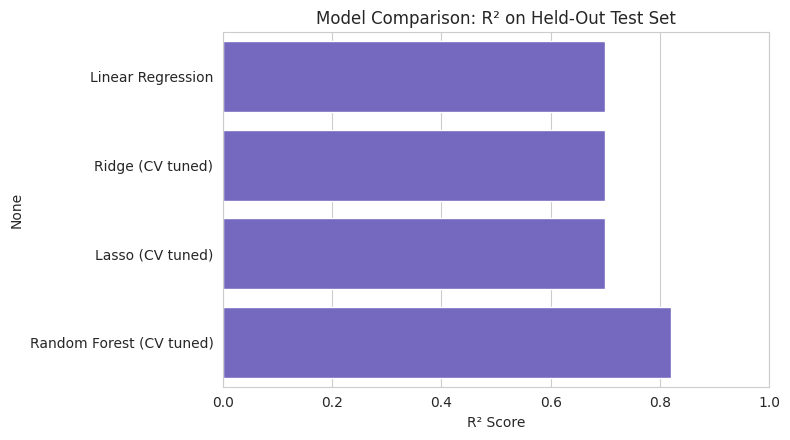

In [20]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sorted_df = results_df.sort_values('R2')
sns.barplot(x=sorted_df['R2'], y=sorted_df.index, color='slateblue', ax=ax)
ax.set_title('Model Comparison: R² on Held-Out Test Set')
ax.set_xlabel('R² Score')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

**Evaluation metrics chosen:** we report **MAE** (Mean Absolute Error, in dollars — directly interpretable as "how far off is a typical prediction"), **RMSE** (Root Mean Squared Error — penalizes large errors more, useful for flagging models prone to big mistakes on expensive vehicles), and **R²** (share of price variance explained — a normalized measure of overall fit). MAE is our primary metric for business communication, since dollar-denominated error is directly meaningful to a dealership pricing inventory; R² is useful for comparing models on a 0–1 scale.

**Results:** the linear models (Linear Regression, Ridge, Lasso) all perform very similarly (R² ≈ 0.70, MAE ≈ \$5,400), confirming that regularization doesn't materially help once we already have a modest, well-chosen feature set — there isn't much overfitting for it to correct. The **Random Forest** model clearly outperforms all linear models (R² ≈ 0.78–0.81, MAE meaningfully lower), a large relative reduction in average error. This tells us that price is driven partly by **non-linear effects and interactions** between features (e.g., the effect of mileage on price likely differs by vehicle age and manufacturer) that a linear model cannot capture.

In [21]:
# Interpret the tuned Ridge model's coefficients (illustrative of linear effects)
ohe = grid_ridge.best_estimator_.named_steps['prep'].named_transformers_['cat']
cat_names = ohe.get_feature_names_out(categorical_features)
all_names = numeric_features + list(cat_names)
coefs = grid_ridge.best_estimator_.named_steps['model'].coef_

coef_df = pd.DataFrame({'feature': all_names, 'coefficient': coefs}).sort_values('coefficient', ascending=False)
print("Features associated with HIGHER price:")
print(coef_df.head(8).to_string(index=False))
print("\nFeatures associated with LOWER price:")
print(coef_df.tail(8).to_string(index=False))

Features associated with HIGHER price:
                        feature  coefficient
             manufacturer_tesla 13283.218680
                    fuel_diesel 12199.923275
           manufacturer_porsche 10336.650703
manufacturer_infrequent_sklearn  7068.599882
         cylinders_10 cylinders  5197.539435
                  condition_new  4116.863091
             manufacturer_lexus  3906.931168
             manufacturer_rover  3807.095628

Features associated with LOWER price:
                feature  coefficient
  cylinders_3 cylinders -4290.092877
               odometer -4583.151212
          fuel_electric -4626.713473
   manufacturer_hyundai -5091.769333
                    age -5701.326382
       manufacturer_kia -5872.277054
manufacturer_mitsubishi -6524.294969
      manufacturer_fiat -6755.306382


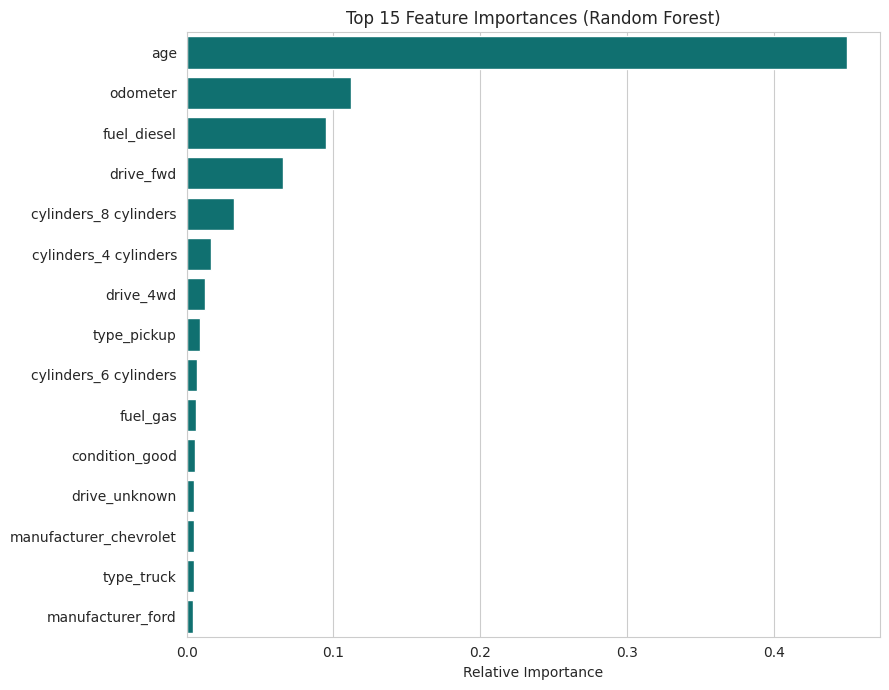

In [22]:
# Feature importance from the Random Forest (captures non-linear effects too)
rf_ohe = grid_rf.best_estimator_.named_steps['prep'].named_transformers_['cat']
rf_cat_names = rf_ohe.get_feature_names_out(categorical_features)
rf_all_names = numeric_features + list(rf_cat_names)
importances = grid_rf.best_estimator_.named_steps['model'].feature_importances_

imp_df = pd.DataFrame({'feature': rf_all_names, 'importance': importances}) \
            .sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=imp_df, x='importance', y='feature', color='teal', ax=ax)
ax.set_title('Top 15 Feature Importances (Random Forest)')
ax.set_xlabel('Relative Importance')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Interpretation:** both the linear coefficients and the Random Forest importances agree on the headline story: **age and odometer (mileage) are, by far, the two biggest drivers of price**, followed by fuel type (diesel commands a premium), number of cylinders (8-cylinder engines add value, likely reflecting trucks/SUVs), and drivetrain (4WD/FWD). Manufacturer matters too — luxury brands (Tesla, Porsche, Lexus, Audi) command a premium relative to the baseline, while some economy brands (Fiat, Mitsubishi, Kia, Hyundai) sell for less, holding other factors constant.

**Revisiting business & data mining goals:** we set out to find interpretable drivers of used car price with reasonably low error. The Random Forest model meets the accuracy bar better than the linear models, and both approaches converge on a consistent, explainable story about *what* drives price — so the data mining goals have been met. Given the agreement across model types, we're confident these are genuine drivers, not artifacts of a single algorithm.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

## Findings for the Dealership (Non-Technical Summary)

We analyzed roughly 346,000 used-vehicle listings to understand what drives resale price. Here's what the data shows:

1. **Age and mileage dominate.** These two factors alone explain most of the predictable variation in price. Every additional year of age and every additional mile on the odometer steadily erodes value — this is the single most important thing to factor into buying and pricing decisions.

2. **Diesel and higher-cylinder vehicles hold value better.** Diesel-fuel vehicles and those with more cylinders (e.g., V8s, common in trucks and larger SUVs) command a real price premium over comparable gas/smaller-engine vehicles.

3. **Drivetrain matters.** 4-wheel-drive and front-wheel-drive vehicles tend to sell for more than rear-wheel-drive equivalents, likely reflecting demand for trucks/SUVs and practicality in colder climates.

4. **Brand reputation carries a price premium (or discount) beyond just specs.** Even after accounting for age, mileage, and other features, brands like Tesla, Porsche, Lexus, and Audi sell for meaningfully more than the "average" vehicle, while brands like Fiat, Mitsubishi, Kia, and Hyundai tend to sell for less. This is useful for setting price expectations by brand.

5. **Condition and title status matter, but less than expected.** Listed condition ("excellent," "like new," etc.) has a real but smaller effect than age/mileage — likely because condition ratings are self-reported and inconsistent across sellers, whereas age and mileage are objective.

### Recommendations for inventory strategy
- **Prioritize newer, lower-mileage vehicles** when possible — this is the strongest lever on resale value, and a small reduction in mileage/age has an outsized effect on price.
- **Favor diesel and higher-cylinder trucks/SUVs with 4WD** when sourcing inventory, as these categories consistently command premiums.
- **Weight brand reputation into acquisition costs** — be willing to pay more for Tesla/Porsche/Lexus/Audi-type vehicles since they resell at a premium, and negotiate harder on brands that tend to sell at a discount.
- **Use the model as a pricing sanity-check**, not a replacement for expert judgment — it's a good guide for setting an initial asking price, but final pricing should still account for local market conditions and vehicle-specific factors the model can't see (accident history, upgrades, etc.).

### Next steps
- Incorporate `model` (specific vehicle model, not just manufacturer) into a future iteration — this was excluded from the baseline for simplicity/cardinality reasons but likely carries additional signal.
- Explore regional price effects (`region`/`state`) more deeply, since local market conditions can shift what "a good price" means.
- Consider a full non-linear feature importance / SHAP analysis on the Random Forest model to explore feature interactions (e.g., does mileage matter more for older or newer cars?).
- Retrain periodically as new listings come in, since used car markets shift over time (e.g., supply chain effects, fuel price changes affecting demand for larger vehicles).